In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nikitagupta1812/regression-practice-dataset/weight_height_dataset_v2.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
df = pd.read_csv('/kaggle/input/datasets/nikitagupta1812/regression-practice-dataset/weight_height_dataset_v2.csv')
df

,Weight,Height
0,95,175
1,105,179
2,99,138
3,65,183
4,53,124
...,...,...
95,88,133
96,106,129
97,108,126
98,63,136


In [4]:
df.head()

,Weight,Height
0,95,175
1,105,179
2,99,138
3,65,183
4,53,124


In [5]:
df.sample()

,Weight,Height
12,110,137


Text(0, 0.5, 'Height')

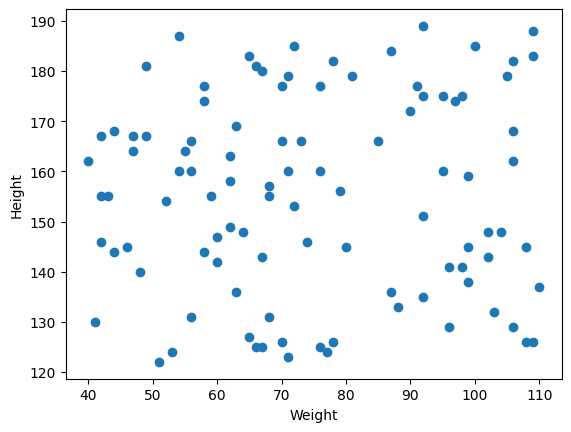

In [6]:
## Scatter Plot 
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')

## we have to analyse it whether it is positive or negative relationship


finding correlation

In [7]:
df.corr()

,Weight,Height
Weight,1.000000,0.025881
Height,0.025881,1.000000


## Seaborn For Visualization


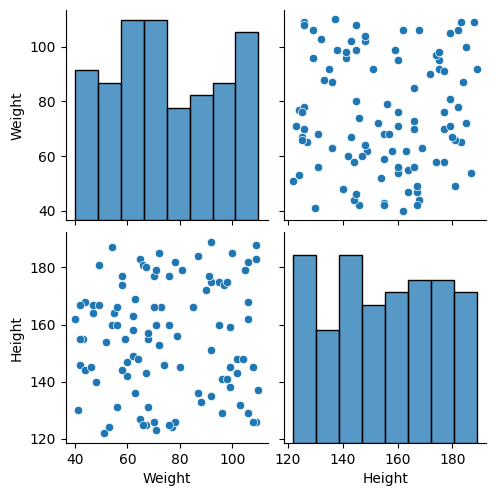

In [8]:
sns.pairplot(df)

## Dividing Features into Independent and Dependent Features
(imp)

In [9]:
df.head()

,Weight,Height
0,95,175
1,105,179
2,99,138
3,65,183
4,53,124


 Independent features ALways in  the Dataframe Or 2- D Array

In [10]:
## Independent Features and Dependent Features 
X = df[['Weight']]
y = df[['Height']] ## This can be in Series Form or 1d Array


In [11]:
X_series = df['Weight']
np.array(X_series).shape

(100,)

In [12]:
np.array(y).shape

(100, 1)

In [13]:
## Train Test Split 
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [14]:
X_train

,Weight
15,77
40,71
96,106
9,47
72,47
...,...
60,54
71,46
14,92
92,56


In [15]:
X_train.shape

(75, 1)

 ## Standardization

In [16]:
from sklearn.preprocessing import StandardScaler


In [17]:
scaler = StandardScaler()
scaler.fit_transform(X_train)

array([[ 0.06489647],
       [-0.21323126],
       [ 1.40918047],
       [-1.32574215],
       [-1.32574215],
       [-0.07416739],
       [-0.21323126],
       [-0.5377136 ],
       [-0.72313208],
       [-0.7694867 ],
       [-0.95490519],
       [-0.39864974],
       [ 1.0383435 ],
       [ 0.01854185],
       [ 0.11125109],
       [ 0.76021578],
       [-1.09396905],
       [ 0.99198888],
       [ 0.5747973 ],
       [ 1.22376199],
       [-1.00125981],
       [ 1.13105274],
       [-0.81584132],
       [ 0.43573343],
       [-1.6502245 ],
       [ 1.54824433],
       [-0.49135898],
       [-1.46480601],
       [ 1.08469812],
       [ 0.11125109],
       [-1.55751526],
       [ 1.40918047],
       [ 1.22376199],
       [ 0.94563426],
       [-0.44500436],
       [-1.51116063],
       [ 0.76021578],
       [ 0.52844268],
       [-0.81584132],
       [ 0.20396033],
       [-0.90855057],
       [-1.55751526],
       [-0.12052201],
       [ 0.94563426],
       [ 1.50188971],
       [ 1

In [18]:
X_test = scaler.transform(X_test)
X_test

array([[-1.60386988],
       [-0.44500436],
       [-0.39864974],
       [-1.27938753],
       [-0.35229512],
       [ 0.89927964],
       [-0.25958588],
       [ 0.71386116],
       [-0.35229512],
       [ 0.89927964],
       [ 0.15760571],
       [-0.49135898],
       [ 0.25031495],
       [ 0.66750654],
       [ 1.31647123],
       [-1.04761443],
       [-0.90855057],
       [ 0.76021578],
       [ 1.59459895],
       [-0.25958588],
       [-0.72313208],
       [-0.81584132],
       [-1.14032367],
       [-0.35229512],
       [-0.39864974]])

## Apply Simple Linear Regression

In [19]:
from sklearn.linear_model import LinearRegression

In [20]:
regression = LinearRegression()

In [21]:
regression.fit(X_train,y_train)

LinearRegression()

In [22]:
regression

LinearRegression()

In [23]:
print("Coffiecient Or Slope",regression.coef_)
print("Intercept",regression.intercept_)

Coffiecient Or Slope [[-0.10371877]]
Intercept [164.40113912]


## Plot the Training Data for best fit line

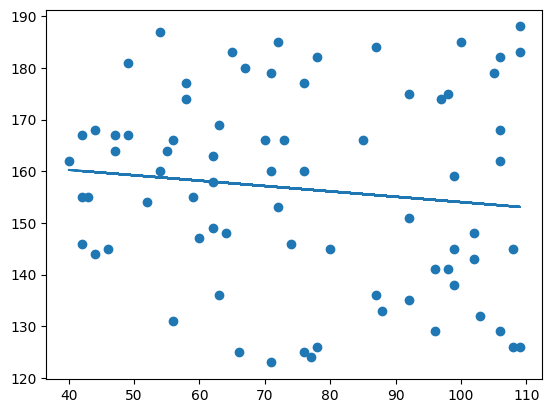

In [24]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train))

 ## Prediction of Test Data
1. predicted height output = intercept + coef_(weights)
2. y_pred_test = (-0.10371877+164.40113912)

In [25]:
## Prediction for test Data
y_pred = regression.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [26]:
## Performance Metrics 
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [27]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

601.2791643496261
21.292771592242257
24.520994358908574


## R SQUARE
Formula

R^2 = 1- SSR/SST
R^2 = Coeffiecient of determination SSR = sum of Square of residuals SST = Total Sum Of Squares


In [28]:
from sklearn.metrics import r2_score


In [29]:
score = r2_score(y_test,y_pred)
print(score)


-0.42566456895596416


    Adjusted R2 = 1-[(1-R2)*(n-1)(n-k-1)]
Where 
R2: The R2 of the Model n: The number of observations k: The Number of predicator Variables

In [30]:
## Display Adjusted R- Squared 
1- (1-score)* (len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

-0.48764998499752776

## OLS Technique

In [31]:
import statsmodels.api as sm

In [32]:
model = sm.OLS(y_train,X_train).fit()

In [33]:
prediction = model.predict(X_test)
print(prediction)

[-3.05883488 -0.84869407 -0.76028844 -2.43999545 -0.67188281  1.71506927
 -0.49507154  1.36144674 -0.67188281  1.71506927  0.30057915 -0.9370997
  0.47739041  1.27304111  2.51071996 -1.99796729 -1.73275039  1.44985237
  3.04115375 -0.49507154 -1.37912786 -1.55593913 -2.17477855 -0.67188281
 -0.76028844]


In [34]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.904
Model:                            OLS   Adj. R-squared (uncentered):              0.903
Method:                 Least Squares   F-statistic:                              697.9
Date:                Fri, 10 Apr 2026   Prob (F-statistic):                    2.03e-39
Time:                        19:18:11   Log-Likelihood:                         -398.03
No. Observations:                  75   AIC:                                      798.1
Df Residuals:                      74   BIC:                                      800.4
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

## PREDICTION FOR NEW DATA

In [35]:
regression.predict(scaler.transform([[72]]))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[164.41844736]])